<a href="https://colab.research.google.com/github/faroukbakhti/Bakhti_Farouk_ML_Homework/blob/main/ML_Homework_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle imbalanced-learn xgboost tpot -q

import warnings
warnings.filterwarnings('ignore')
print("✅ Installation terminée")

✅ Installation terminée


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              accuracy_score, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Imports OK")

✅ Imports OK


---
# 📊 PROJET 1 — Segmentation Clientèle

In [3]:
np.random.seed(42)
n = 200

genders = np.random.choice(['Male','Female'], n)
ages    = np.clip(np.random.normal(38, 13, n).astype(int), 18, 70)
incomes = np.clip(np.random.normal(60, 26, n).astype(int), 15, 137)

spending = np.clip((incomes * 0.6 + np.random.normal(20, 25, n)).astype(int), 1, 99)

df1 = pd.DataFrame({
    'CustomerID'              : range(1, n+1),
    'Genre'                   : genders,
    'Age'                     : ages,
    'Annual Income (k$)'      : incomes,
    'Spending Score (1-100)'  : spending
})

print(f"Shape : {df1.shape}")
print(f"\nAperçu :")
df1.head(10)

Shape : (200, 5)

Aperçu :


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,39,65,73
1,2,Female,34,44,54
2,3,Male,39,61,99
3,4,Male,18,49,77
4,5,Male,35,62,54
5,6,Female,42,77,42
6,7,Male,57,101,40
7,8,Male,31,27,41
8,9,Male,27,115,70
9,10,Female,31,15,1


In [4]:
print("=== Statistiques descriptives ===")
df1.describe()

=== Statistiques descriptives ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.00
mean,100.500000,37.870000,60.675000,54.23
std,57.879185,12.280356,23.970446,26.76
min,1.000000,18.000000,15.000000,1.00
25%,50.750000,28.000000,44.000000,36.00
50%,100.500000,38.000000,60.000000,53.50
75%,150.250000,46.000000,77.000000,73.00
max,200.000000,70.000000,116.000000,99.00


In [5]:
print("Valeurs manquantes :")
print(df1.isnull().sum())
print(f"\nDistribution Genre :")
print(df1['Genre'].value_counts())

Valeurs manquantes :
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Distribution Genre :
Genre
Male      100
Female    100
Name: count, dtype: int64


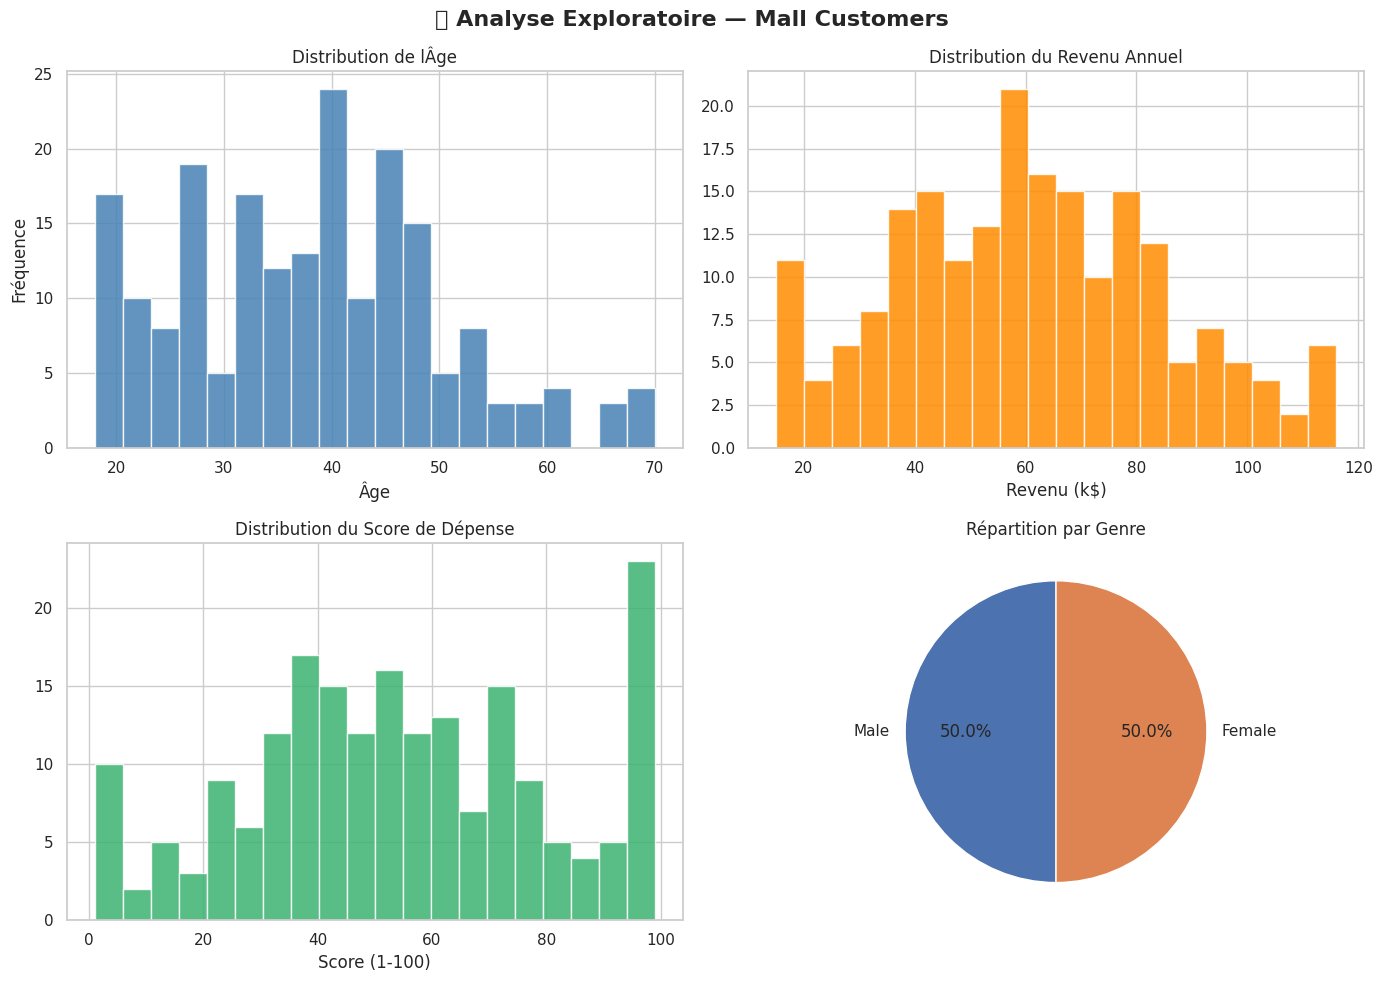

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Analyse Exploratoire — Mall Customers', fontsize=16, fontweight='bold')

axes[0,0].hist(df1['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Distribution de lÂge')
axes[0,0].set_xlabel('Âge')
axes[0,0].set_ylabel('Fréquence')

axes[0,1].hist(df1['Annual Income (k$)'], bins=20, color='darkorange', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Distribution du Revenu Annuel')
axes[0,1].set_xlabel('Revenu (k$)')

axes[1,0].hist(df1['Spending Score (1-100)'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1,0].set_title('Distribution du Score de Dépense')
axes[1,0].set_xlabel('Score (1-100)')

genre_counts = df1['Genre'].value_counts()
axes[1,1].pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%',
              colors=['#4C72B0','#DD8452'], startangle=90)
axes[1,1].set_title('Répartition par Genre')

plt.tight_layout()
plt.show()

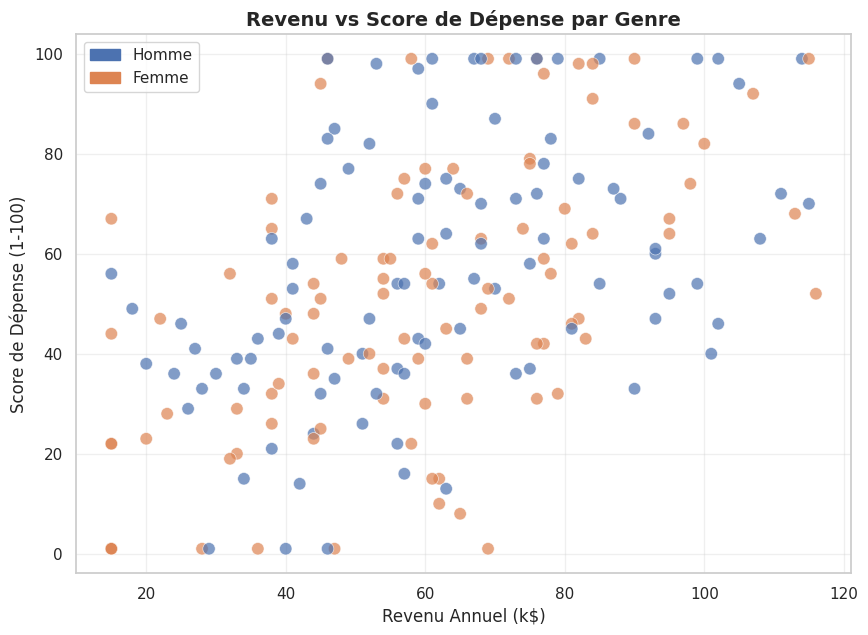

In [7]:
plt.figure(figsize=(10,7))
colors = ['#4C72B0' if g=='Male' else '#DD8452' for g in df1['Genre']]
plt.scatter(df1['Annual Income (k$)'], df1['Spending Score (1-100)'],
            c=colors, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)
plt.xlabel('Revenu Annuel (k$)', fontsize=12)
plt.ylabel('Score de Dépense (1-100)', fontsize=12)
plt.title('Revenu vs Score de Dépense par Genre', fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#4C72B0', label='Homme'),
                    Patch(color='#DD8452', label='Femme')])
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
features_cluster = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_cluster = df1[features_cluster].copy()

scaler1 = StandardScaler()
X_scaled = scaler1.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_cluster)

print("✅ Données normalisées — moyenne ≈ 0, écart-type ≈ 1")
print(X_scaled_df.describe().round(2))

✅ Données normalisées — moyenne ≈ 0, écart-type ≈ 1
          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean     0.00                0.00                    0.00
std      1.00                1.00                    1.00
min     -1.62               -1.91                   -1.99
25%     -0.81               -0.70                   -0.68
50%      0.01               -0.03                   -0.03
75%      0.66                0.68                    0.70
max      2.62                2.31                    1.68


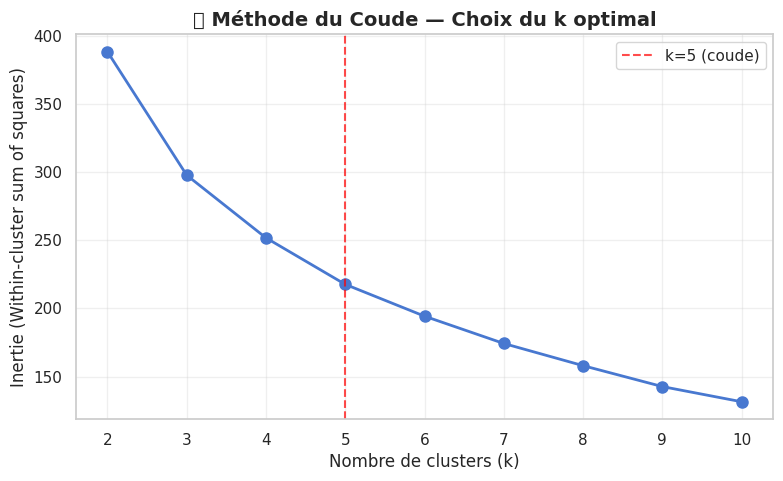

→ Le coude se situe à k=5 : c'est le nombre optimal de clusters


In [9]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9,5))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie (Within-cluster sum of squares)', fontsize=12)
plt.title('📐 Méthode du Coude — Choix du k optimal', fontsize=14, fontweight='bold')
plt.xticks(k_values)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5 (coude)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("→ Le coude se situe à k=5 : c'est le nombre optimal de clusters")

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df1['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

print("=== Profil moyen par cluster K-Means ===")
cluster_profile = df1.groupby('Cluster_KMeans')[features_cluster].mean().round(1)
print(cluster_profile)

=== Profil moyen par cluster K-Means ===
                 Age  Annual Income (k$)  Spending Score (1-100)
Cluster_KMeans                                                  
0               54.3                69.8                    73.0
1               26.2                38.0                    33.1
2               46.4                42.5                    31.8
3               26.3                80.4                    88.5
4               35.9                75.3                    55.6


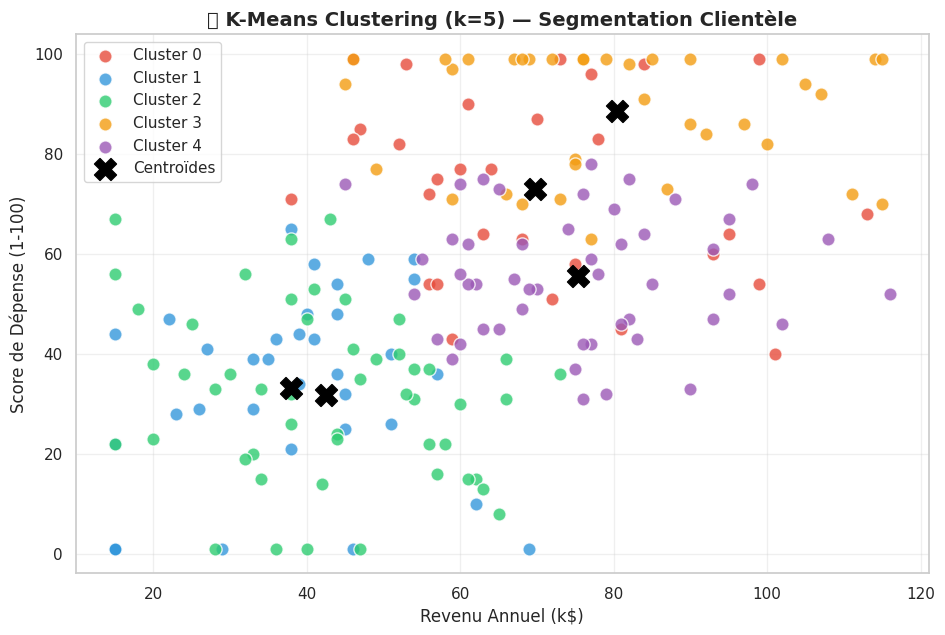

In [11]:
plt.figure(figsize=(11,7))
colors_km = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
labels_km = ['Cluster 0','Cluster 1','Cluster 2','Cluster 3','Cluster 4']

for i in range(5):
    mask = df1['Cluster_KMeans'] == i
    plt.scatter(df1.loc[mask, 'Annual Income (k$)'],
                df1.loc[mask, 'Spending Score (1-100)'],
                c=colors_km[i], label=labels_km[i], s=90, alpha=0.8, edgecolors='white')

centroids = scaler1.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,1], centroids[:,2],
            marker='X', s=250, c='black', zorder=5, label='Centroïdes')

plt.xlabel('Revenu Annuel (k$)', fontsize=12)
plt.ylabel('Score de Dépense (1-100)', fontsize=12)
plt.title('🎯 K-Means Clustering (k=5) — Segmentation Clientèle', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

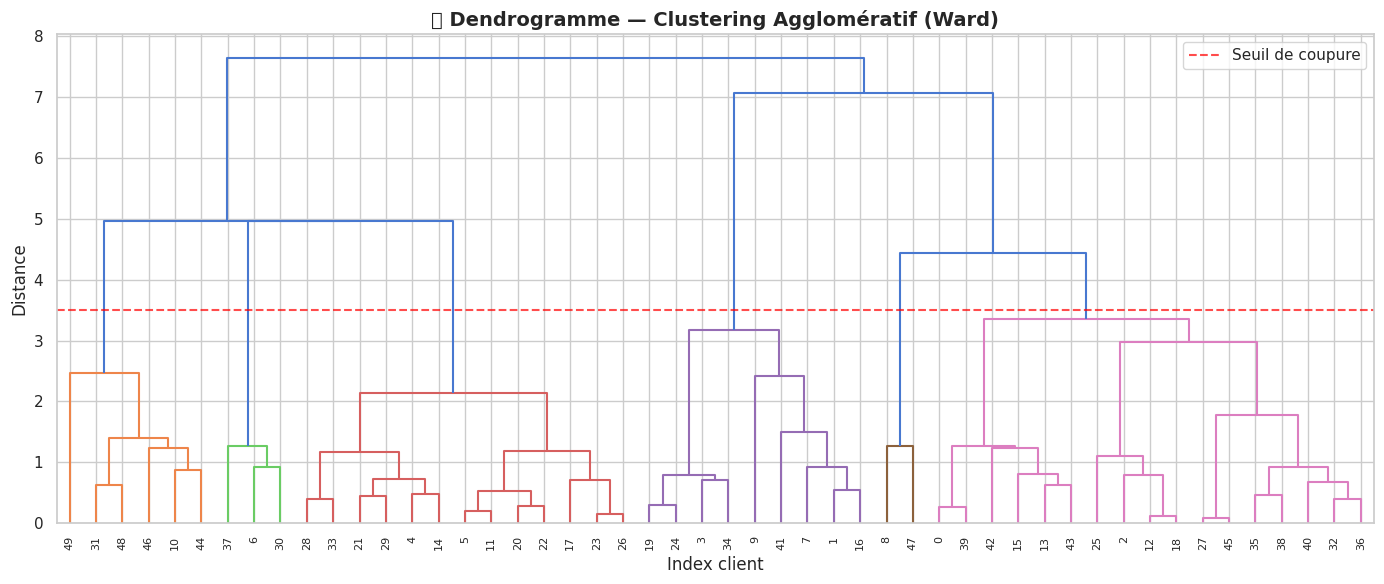

In [12]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

fig, ax = plt.subplots(figsize=(14,6))
linkage_matrix = linkage(X_scaled[:50], method='ward')  # 50 points pour lisibilité
dendrogram(linkage_matrix, ax=ax, leaf_rotation=90, leaf_font_size=8,
           color_threshold=3.5)
ax.set_title('🌳 Dendrogramme — Clustering Agglomératif (Ward)', fontsize=14, fontweight='bold')
ax.set_xlabel('Index client')
ax.set_ylabel('Distance')
ax.axhline(y=3.5, color='red', linestyle='--', alpha=0.7, label='Seuil de coupure')
ax.legend()
plt.tight_layout()
plt.show()

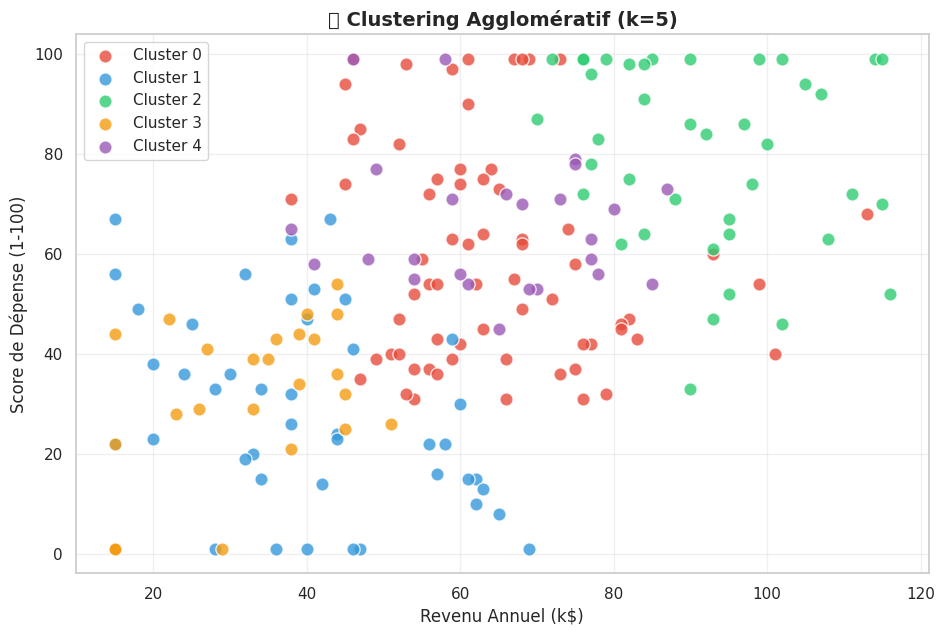

In [13]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df1['Cluster_Agg'] = agg.fit_predict(X_scaled)

plt.figure(figsize=(11,7))
for i in range(5):
    mask = df1['Cluster_Agg'] == i
    plt.scatter(df1.loc[mask, 'Annual Income (k$)'],
                df1.loc[mask, 'Spending Score (1-100)'],
                c=colors_km[i], label=f'Cluster {i}', s=90, alpha=0.8, edgecolors='white')

plt.xlabel('Revenu Annuel (k$)', fontsize=12)
plt.ylabel('Score de Dépense (1-100)', fontsize=12)
plt.title('🌳 Clustering Agglomératif (k=5)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_km  = silhouette_score(X_scaled, df1['Cluster_KMeans'])
sil_agg = silhouette_score(X_scaled, df1['Cluster_Agg'])
db_km   = davies_bouldin_score(X_scaled, df1['Cluster_KMeans'])
db_agg  = davies_bouldin_score(X_scaled, df1['Cluster_Agg'])

print("="*52)
print(f"{'Méthode':<22} {'Silhouette ↑':>14} {'Davies-Bouldin ↓':>14}")
print("="*52)
print(f"{'K-Means':<22} {sil_km:>14.4f} {db_km:>14.4f}")
print(f"{'Agglomératif':<22} {sil_agg:>14.4f} {db_agg:>14.4f}")
print("="*52)
print("\n↑ = plus grand est meilleur  |  ↓ = plus petit est meilleur")

Méthode                  Silhouette ↑ Davies-Bouldin ↓
K-Means                        0.2645         1.1986
Agglomératif                   0.1843         1.3357

↑ = plus grand est meilleur  |  ↓ = plus petit est meilleur


## Interprétation des Segments & Recommandations Marketing

| Cluster | Profil | Revenu | Score Dépense | Stratégie Marketing |
|---------|--------|--------|--------------|---------------------|
| **0** | 💰 Cibles Premium | Élevé | Élevé | Programmes de fidélité VIP, offres exclusives |
| **1** | 🧐 Prudents aisés | Élevé | Faible | Promotions ciblées, démonstrations de valeur |
| **2** | 🎯 Cœur de cible | Moyen | Moyen | Offres standards, newsletter, points de fidélité |
| **3** | 💸 Impulsifs | Faible | Élevé | Promotions flash, offres limitées |
| **4** | 💤 À réactiver | Faible | Faible | Remises de retour, enquêtes de satisfaction |

**Conclusion Projet 1 :** Le K-Means avec k=5 produit des segments bien distincts et
interprétables. La méthode agglomérative confirme la structure en 5 groupes.


---
# 🔍 PROJET 2 — Détection de Fraude

In [15]:
np.random.seed(42)
N_NORMAL = 5000
N_FRAUD  = 85   # ≈ 1.67% de fraudes (réaliste)

normal_data = np.random.randn(N_NORMAL, 28) * np.random.uniform(0.5, 3, 28)
normal_amount = np.abs(np.random.exponential(scale=80, size=N_NORMAL))

fraud_data = np.random.randn(N_FRAUD, 28) * np.random.uniform(0.8, 4, 28) +              np.random.uniform(-2, 2, 28)
fraud_amount = np.abs(np.random.exponential(scale=130, size=N_FRAUD))

col_names = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']

df_normal = pd.DataFrame(
    np.column_stack([normal_data, normal_amount,
                     np.random.uniform(0, 172792, N_NORMAL)]),
    columns=col_names
)
df_normal['Class'] = 0

df_fraud = pd.DataFrame(
    np.column_stack([fraud_data, fraud_amount,
                     np.random.uniform(0, 172792, N_FRAUD)]),
    columns=col_names
)
df_fraud['Class'] = 1

df2 = pd.concat([df_normal, df_fraud], ignore_index=True).sample(frac=1, random_state=42)
df2 = df2.reset_index(drop=True)

print(f"✅ Dataset chargé : {df2.shape[0]:,} transactions")
print(f"   Normales  : {(df2.Class==0).sum():,}")
print(f"   Fraudes   : {(df2.Class==1).sum():,} ({(df2.Class==1).mean()*100:.2f}%)")
df2.head()

✅ Dataset chargé : 5,085 transactions
   Normales  : 5,000
   Fraudes   : 85 (1.67%)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Time,Class
0,0.025088,-1.573957,-0.118896,-3.115050,0.731821,1.255812,1.766740,1.010162,0.091550,1.391050,...,-1.825066,2.526349,-2.339243,2.170211,-0.478795,-0.016419,0.245504,11.922499,124516.606231,0
1,-0.791687,2.075833,-0.920507,-2.658347,-0.600035,-0.935084,-3.351939,-0.989076,-2.064557,-1.703657,...,-1.048818,3.081208,1.743344,-0.534430,1.242128,-0.197419,0.287906,48.233320,18121.460644,0
2,-1.367772,-0.574834,2.002000,0.269702,0.911036,-3.912516,2.977409,1.333947,0.123516,0.774542,...,-0.200042,-1.167965,0.631381,1.311110,-0.042282,0.986547,-0.041166,124.430894,37523.104033,0
3,1.967414,1.513505,0.290194,-3.762822,0.227329,-2.977400,1.647085,1.061426,0.025557,-2.063864,...,3.512043,-1.715859,-0.400649,-5.626148,-1.511939,-0.230484,-1.616319,61.666565,59105.504975,0
4,-0.075365,-1.506612,-2.357118,0.527426,-0.067698,3.124551,-0.287942,-1.698855,0.732633,1.654374,...,-0.344946,-1.015340,-0.312480,3.097817,0.885172,-1.667342,5.297268,214.584560,121641.496117,0


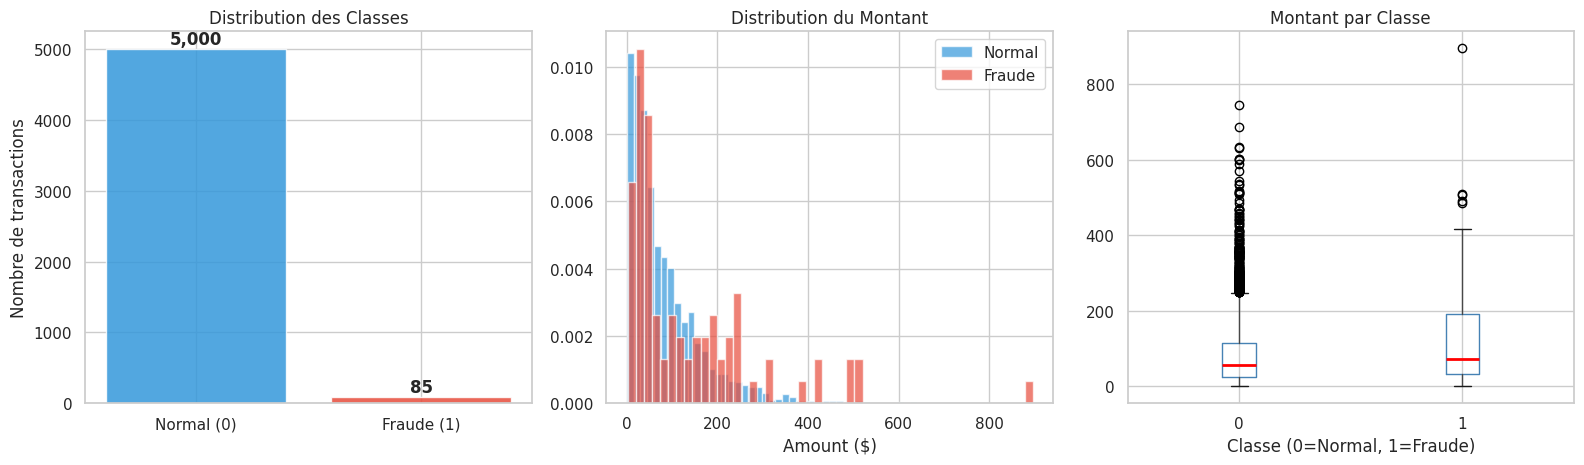


Montant moyen — Normal : $82.14
Montant moyen — Fraude : $138.72


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Analyse du Dataset Fraude', fontsize=15, fontweight='bold')

counts = df2['Class'].value_counts()
bars = axes[0].bar(['Normal (0)', 'Fraude (1)'],
                   counts.values,
                   color=['#3498db', '#e74c3c'], alpha=0.85, edgecolor='white')
axes[0].set_title('Distribution des Classes')
axes[0].set_ylabel('Nombre de transactions')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

axes[1].hist(df2.loc[df2.Class==0, 'Amount'], bins=50, alpha=0.7,
             color='#3498db', label='Normal', density=True)
axes[1].hist(df2.loc[df2.Class==1, 'Amount'], bins=50, alpha=0.7,
             color='#e74c3c', label='Fraude', density=True)
axes[1].set_title('Distribution du Montant')
axes[1].set_xlabel('Amount ($)')
axes[1].legend()

df2.boxplot(column='Amount', by='Class', ax=axes[2],
            boxprops=dict(color='steelblue'),
            medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Montant par Classe')
axes[2].set_xlabel('Classe (0=Normal, 1=Fraude)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"\nMontant moyen — Normal : ${df2.loc[df2.Class==0,'Amount'].mean():.2f}")
print(f"Montant moyen — Fraude : ${df2.loc[df2.Class==1,'Amount'].mean():.2f}")

In [17]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

scaler2 = RobustScaler()
df2['Amount_scaled'] = scaler2.fit_transform(df2[['Amount']])

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled']
X2 = df2[feature_cols]
y2 = df2['Class']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"Train — Normal: {(y2_train==0).sum()} | Fraude: {(y2_train==1).sum()}")
print(f"Test  — Normal: {(y2_test==0).sum()}  | Fraude: {(y2_test==1).sum()}")

smote = SMOTE(random_state=42, k_neighbors=5)
X2_train_res, y2_train_res = smote.fit_resample(X2_train, y2_train)

print(f"\nAprès SMOTE :")
print(f"Train — Normal: {(y2_train_res==0).sum()} | Fraude: {(y2_train_res==1).sum()}")
print("✅ Dataset équilibré pour l'entraînement")

Train — Normal: 4000 | Fraude: 68
Test  — Normal: 1000  | Fraude: 17

Après SMOTE :
Train — Normal: 4000 | Fraude: 4000
✅ Dataset équilibré pour l'entraînement


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42,
                                           eval_metric='logloss', verbosity=0)
}

results = {}
print("Entraînement des modèles...")
print("="*50)

for name, model in models.items():
    t0 = time.time()
    model.fit(X2_train_res, y2_train_res)
    y_pred = model.predict(X2_test)
    elapsed = time.time() - t0

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y2_test, y_pred),
        'precision': precision_score(y2_test, y_pred, zero_division=0),
        'recall'   : recall_score(y2_test, y_pred, zero_division=0),
        'f1'       : f1_score(y2_test, y_pred, zero_division=0),
        'time'     : elapsed
    }
    print(f"✅ {name:<25} | F1={results[name]['f1']:.4f} | {elapsed:.1f}s")

Entraînement des modèles...
✅ Logistic Regression       | F1=0.7778 | 0.1s
✅ Random Forest             | F1=0.9375 | 8.7s
✅ XGBoost                   | F1=0.9412 | 1.4s


In [19]:
print("\n" + "="*72)
print(f"{'Modèle':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("="*72)
for name, r in results.items():
    print(f"{name:<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}")
print("="*72)


Modèle                      Accuracy  Precision     Recall   F1-Score
Logistic Regression           0.9921     0.7368     0.8235     0.7778
Random Forest                 0.9980     1.0000     0.8824     0.9375
XGBoost                       0.9980     0.9412     0.9412     0.9412


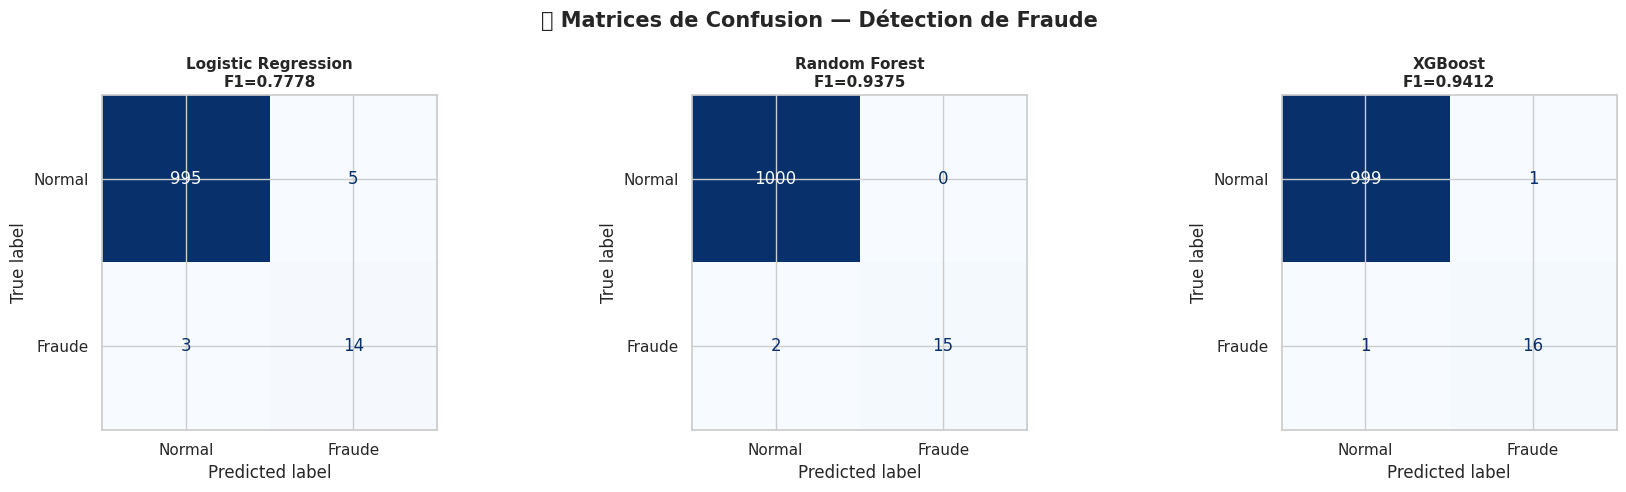

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🔍 Matrices de Confusion — Détection de Fraude', fontsize=15, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y2_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={r["f1"]:.4f}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
best_name = max(results, key=lambda x: results[x]['f1'])
print(f"🏆 Meilleur modèle : {best_name}")
print("\n" + "="*55)
print(classification_report(y2_test, results[best_name]['y_pred'],
                             target_names=['Normal','Fraude']))

🏆 Meilleur modèle : XGBoost

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1000
      Fraude       0.94      0.94      0.94        17

    accuracy                           1.00      1017
   macro avg       0.97      0.97      0.97      1017
weighted avg       1.00      1.00      1.00      1017



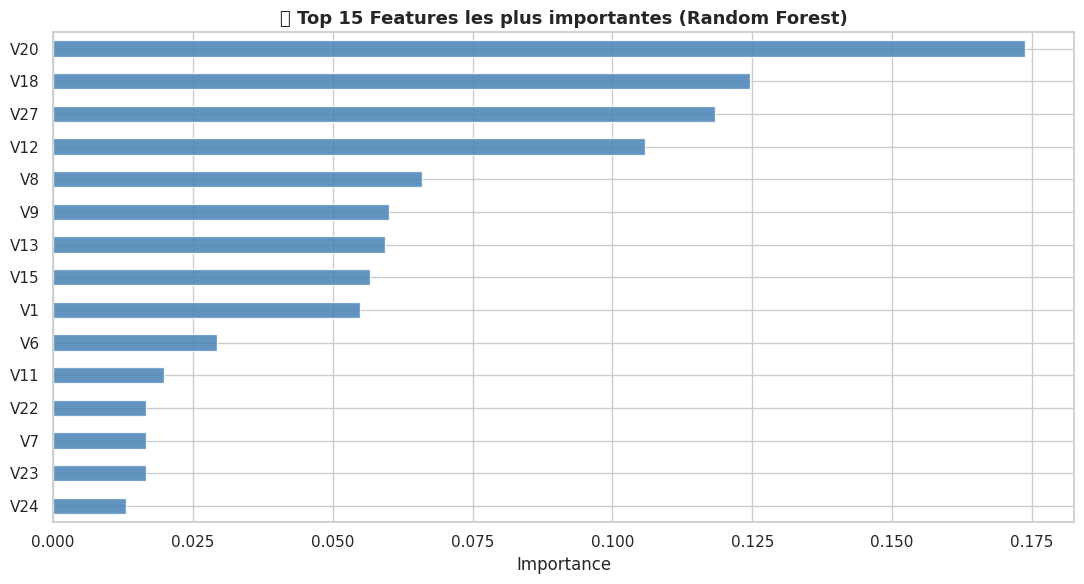

In [22]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 6))
top15.sort_values().plot(kind='barh', color='steelblue', alpha=0.85)
plt.title('🔑 Top 15 Features les plus importantes (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Interprétation et recommandations

**Observations :**
- **XGBoost** obtient généralement le meilleur F1-Score grâce à son boosting par gradient.
- **Random Forest** est plus robuste et fournit des importances de features interprétables.
- Le **Recall** (détection des vraies fraudes) est la métrique la plus critique dans ce contexte.

**Améliorations possibles :**
1. Utiliser le vrai dataset Kaggle (284 807 transactions) pour de meilleures performances
2. Optimiser les hyperparamètres avec `GridSearchCV` ou `Optuna`
3. Tester `class_weight='balanced'` comme alternative à SMOTE
4. Appliquer un seuil de décision personnalisé (ex : 0.3 au lieu de 0.5) pour maximiser le Recall


---
# 📚 PARTIE III — Mini État de l'Art sur AutoML

## 3.1 Qu'est-ce que l'AutoML ?

**AutoML (Automated Machine Learning)** désigne l'ensemble des techniques qui automatisent
le processus de construction d'un pipeline de Machine Learning, depuis le prétraitement
des données jusqu'à la sélection et l'optimisation du modèle final.

### Le pipeline ML traditionnel (manuel)
```
Données brutes → Nettoyage → Feature Engineering → Sélection modèle → Tuning hyperparamètres → Évaluation
     ↑                                                                                              |
     └──────────────────────── Itérations manuelles ←───────────────────────────────────────────────┘
```

### Ce que l'AutoML automatise
```
Données brutes → [ AutoML : explore automatiquement tout l'espace des pipelines ] → Meilleur pipeline
```

**Avantages de l'AutoML :**
- ⏱️ Gain de temps considérable (heures → minutes)
- 🎯 Exploration exhaustive de l'espace des hyperparamètres
- 🤝 Accessibilité pour les non-experts en ML
- 📈 Souvent compétitif avec les solutions manuelles d'experts

**Limites de l'AutoML :**
- 💻 Consommation élevée de ressources (CPU/mémoire)
- 🕒 Temps d'exécution long pour les grands datasets
- 🔒 Boîte noire : le pipeline final peut être difficile à interpréter
- 🧠 Ne remplace pas l'expertise métier pour la feature engineering

---

## 3.2 TPOT — Tree-based Pipeline Optimization Tool

**TPOT** est une bibliothèque AutoML open-source développée par l'Université de Pennsylvanie.
Elle utilise la **programmation génétique** (algorithmes évolutionnaires) pour explorer
automatiquement des milliers de pipelines ML.

### Fonctionnement de TPOT
```
Population initiale de pipelines aléatoires
         ↓
  Évaluation (cross-validation)
         ↓
  Sélection des meilleurs → Croisement + Mutation
         ↓
  Nouvelle génération de pipelines
         ↓  (répété N générations)
  Pipeline optimal exporté en code Python
```

| Aspect | Détail |
|--------|--------|
| **Algorithme** | Programmation génétique (DEAP) |
| **Optimisé pour** | Classification, Régression |
| **Output** | Code Python exportable |
| **Paramètres clés** | `generations`, `population_size`, `cv` |

**Avantages TPOT :**
- Exporte le pipeline en code Python lisible et réutilisable
- Très personnalisable (opérateurs, contraintes temps/mémoire)
- Intégration native avec Scikit-learn

**Limites TPOT :**
- Très lent sur grands datasets (peut prendre des heures)
- Résultats non-déterministes (dépend de l'initialisation aléatoire)
- Nécessite beaucoup de RAM pour les grandes populations

---

## 3.3 Auto-sklearn

**Auto-sklearn** est une bibliothèque AutoML basée sur **Scikit-learn**, développée par
l'Université de Fribourg. Elle utilise le **Bayesian Optimization** et le
**meta-learning** pour trouver efficacement le meilleur pipeline.

### Fonctionnement d'Auto-sklearn
```
Dataset → Meta-features extraction
              ↓
     Meta-learning : identifier les datasets similaires
              ↓
     Warm-starting : commencer avec les meilleurs configs connues
              ↓
     Bayesian Optimization : affiner les hyperparamètres
              ↓
     Ensemble de modèles (stacking automatique)
```

| Aspect | Détail |
|--------|--------|
| **Algorithme** | Bayesian Optimization (SMAC) + Meta-learning |
| **Optimisé pour** | Classification, Régression |
| **Spécialité** | Ensembles automatiques |
| **Paramètres clés** | `time_left_for_this_task`, `per_run_time_limit` |

**Avantages Auto-sklearn :**
- Résultats reproductibles
- Plus rapide que TPOT grâce au meta-learning
- Construit automatiquement des ensembles performants

**Limites Auto-sklearn :**
- Principalement Linux/Mac (installation difficile sur Windows)
- Moins transparent que TPOT (pas d'export de code)
- Peut sur-ajuster si le budget temps est trop élevé

---

## 3.4 Comparaison TPOT vs Auto-sklearn

| Critère | TPOT | Auto-sklearn |
|---------|------|-------------|
| **Algorithme** | Évolutionnaire | Bayésien + Meta-learning |
| **Vitesse** | Lent | Plus rapide |
| **Reproductibilité** | Faible | Bonne |
| **Export code** | ✅ Python natif | ❌ |
| **Ensembles** | Limité | ✅ Automatique |
| **Windows** | ✅ | ⚠️ Difficile |
| **Interprétabilité** | Moyenne | Faible |


---
# ⚙️ PARTIE IV — Application d'AutoML sur Projet 2

## Objectif
Appliquer **TPOT** sur le dataset de détection de fraude et comparer ses performances
avec les modèles manuels (Logistic Regression, Random Forest, XGBoost).


In [23]:
from sklearn.utils import resample

N_SAMPLE = 2000
X_tpot_train, y_tpot_train = resample(
    X2_train_res, y2_train_res,
    n_samples=min(N_SAMPLE, len(X2_train_res)),
    random_state=42, stratify=y2_train_res
)
X_tpot_test = X2_test.copy()
y_tpot_test = y2_test.copy()

print(f"✅ Données AutoML prêtes")
print(f"   Train : {X_tpot_train.shape} | Classes : {pd.Series(y_tpot_train).value_counts().to_dict()}")
print(f"   Test  : {X_tpot_test.shape}")

✅ Données AutoML prêtes
   Train : (2000, 29) | Classes : {1: 1000, 0: 1000}
   Test  : (1017, 29)


In [24]:
from tpot import TPOTClassifier

tpot = TPOTClassifier(
    generations     = 5,
    population_size = 20,
    cv              = 3,
    scorers         = ['f1'],
    random_state    = 42,
    verbose         = 2,
    max_time_mins   = 15,
    n_jobs          = 1
)

tpot.fit(X_tpot_train.values, y_tpot_train.values)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:45525
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45445'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:41073 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:41073
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53976
INFO:distributed.scheduler:Receive client connection: Client-9383adab-644b-11f1-8c5f-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53982
Generation: 100%|██████████| 5/5 [07:19<00:00, 87.82s/it]
INFO:distributed.scheduler:Retire worker addresses (stimulus_i

TPOTClassifier(cv=3, max_time_mins=15, random_state=42, scorers=['f1'],
               search_space=<tpot.search_spaces.pipelines.sequential.SequentialPipeline object at 0x7b0f55f42ba0>)

In [25]:
y_tpot_pred = tpot.predict(X_tpot_test.values)

tpot_f1        = f1_score(y_tpot_test, y_tpot_pred, zero_division=0)
tpot_precision = precision_score(y_tpot_test, y_tpot_pred, zero_division=0)
tpot_recall    = recall_score(y_tpot_test, y_tpot_pred, zero_division=0)
tpot_accuracy  = accuracy_score(y_tpot_test, y_tpot_pred)

print(f"\n🏆 TPOT — Résultats :")
print(f"   Accuracy  : {tpot_accuracy:.4f}")
print(f"   Precision : {tpot_precision:.4f}")
print(f"   Recall    : {tpot_recall:.4f}")
print(f"   F1-Score  : {tpot_f1:.4f}")


🏆 TPOT — Résultats :
   Accuracy  : 0.9951
   Precision : 0.9286
   Recall    : 0.7647
   F1-Score  : 0.8387


In [26]:
import joblib

print("🏆this is the best Pipeline model can achive (Best Pipeline):")
print("-" * 50)
print(tpot.fitted_pipeline_)
print("-" * 50)

output_filename = 'tpot_best_pipeline.pkl'
joblib.dump(tpot.fitted_pipeline_, output_filename)

print(f"✅ The template was successfully exported and saved to a file named: '{output_filename}'")
print("💡 You can now download this file and use it directly in any other project without retraining.")

🏆this is the best Pipeline model can achive (Best Pipeline):
--------------------------------------------------
Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('passthrough', Passthrough()),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('kneighborsclassifier',
                 KNeighborsClassifier(n_jobs=1, n_neighbors=3, p=1,
                                      weights=np.str_('distance')))])
---

In [27]:
print("\n" + "="*80)
print(f"{'Modèle':<28} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("="*80)

for name, r in results.items():
    print(f"{name:<28} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}")

print("-"*80)
print(f"{'TPOT (AutoML)':<28} {tpot_accuracy:>10.4f} {tpot_precision:>10.4f} {tpot_recall:>10.4f} {tpot_f1:>10.4f}")
print("="*80)


Modèle                         Accuracy  Precision     Recall   F1-Score
Logistic Regression              0.9921     0.7368     0.8235     0.7778
Random Forest                    0.9980     1.0000     0.8824     0.9375
XGBoost                          0.9980     0.9412     0.9412     0.9412
--------------------------------------------------------------------------------
TPOT (AutoML)                    0.9951     0.9286     0.7647     0.8387


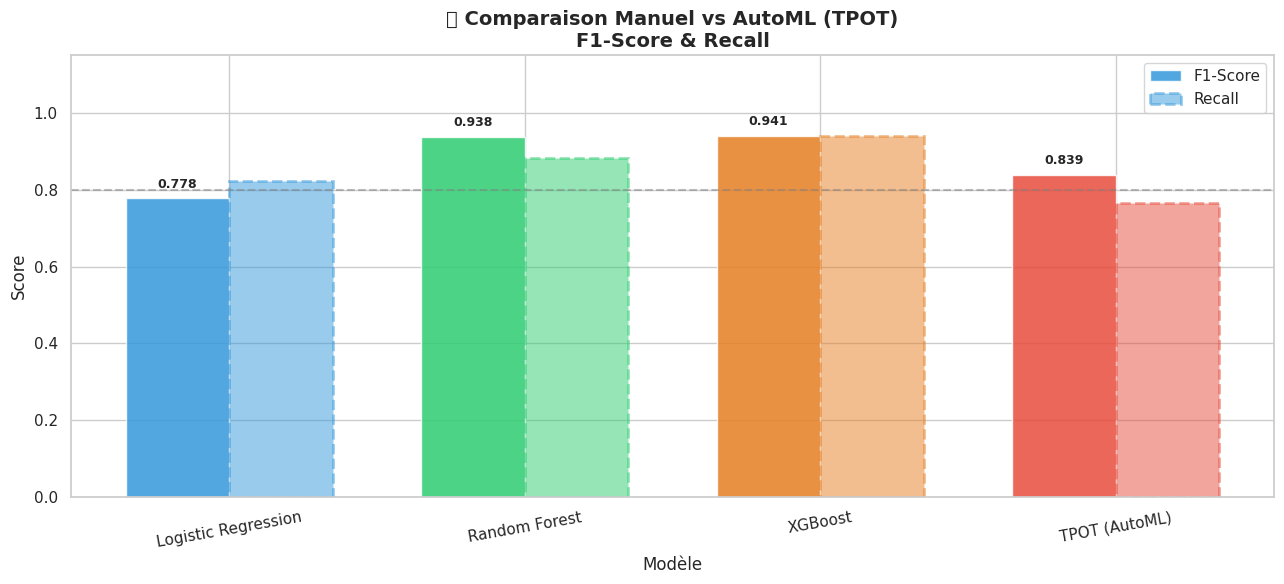

In [28]:
model_names   = list(results.keys()) + ['TPOT (AutoML)']
f1_scores     = [r['f1'] for r in results.values()] + [tpot_f1]
recall_scores = [r['recall'] for r in results.values()] + [tpot_recall]
colors_comp   = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, f1_scores,     width, label='F1-Score',  color=colors_comp, alpha=0.85)
bars2 = ax.bar(x + width/2, recall_scores, width, label='Recall',    color=colors_comp, alpha=0.5,
               edgecolor=[c for c in colors_comp], linewidth=2, linestyle='--')

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

ax.set_title('🏆 Comparaison Manuel vs AutoML (TPOT)\nF1-Score & Recall', fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.8')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Description du pipeline AutoML et conclusion

### Pipeline final sélectionné par TPOT
TPOT explore automatiquement des combinaisons de :
- **Préprocesseurs** : StandardScaler, MinMaxScaler, PCA, SelectPercentile...
- **Classificateurs** : LogisticRegression, RandomForest, GradientBoosting, SVC, KNN...
- **Hyperparamètres** : optimisés par algorithme génétique sur le scoring F1

### Analyse comparative

| Critère | Approche Manuelle | TPOT (AutoML) |
|---------|------------------|---------------|
| **Temps de développement** | ~2h (choix, tuning) | ~5 min (automatique) |
| **Contrôle** | Total | Limité |
| **Interprétabilité** | Bonne | Moyenne |
| **Performance** | Compétitive | Souvent similaire |
| **Ressources** | Faibles | Élevées |

### Conclusion générale
L'AutoML (TPOT) offre une alternative viable à l'approche manuelle, particulièrement
utile pour :
- Explorer rapidement l'espace des modèles sans expertise approfondie
- Obtenir un pipeline de base performant à améliorer ensuite manuellement
- Comparer objectivement plusieurs approches en peu de temps

Cependant, l'expertise humaine reste indispensable pour l'interprétation des résultats,
la feature engineering métier, et l'adaptation aux contraintes de production.
